# Loading your BWK sample points.
## Loading packages
Let's start with installing the required packages.

In [21]:
%pip install "geotessera==0.8.0"

In [22]:
try:
    import ee, geemap
except ImportError:
    !pip -q install earthengine-api geemap

import ee, geemap, datetime # ee: Google Earth Engine (GEE) API, geemap: mapping GEE products
import pandas as pd
import matplotlib.pyplot as plt # for figure plotting
import geopandas as gpd # for geospatial dataframes
import os

In [23]:
%pip install "leafmap[maplibre]" # For interactive visualization of maps.
from maplibre.plugins import MapboxDrawControls, MapboxDrawOptions # To select ROI's on your maps.

Connect to your Google Drive to load your dataset within your drive.

In [24]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Load your geospatial dataset.

In [25]:
grasslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/Grassland_classified_final_classes_2019.gpkg")
nograsslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/NoGrassland_classified_final_classes_2019.gpkg")

Create a random subset of nograsslands of +/- 30% of the grasslands dataset.

In [26]:
samplesize = round(len(grasslands) * 30  / 100)
samplesize

2022

In [27]:
nograsslands_samp = nograsslands.sample(n=samplesize, random_state=42)
len(nograsslands_samp)

2022

Combine the datasets

In [28]:
list(grasslands)

['lg_2022',
 'lg_2016',
 'lg_2017',
 'lg_2018',
 'lg_2019',
 'lg_2020',
 'lg_2021',
 'l_7_BWK',
 'lg_2023',
 'Tl_2023',
 'l_8_BWK',
 'FID_BWK',
 'OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABE',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHA',
 'HABLEGE',
 'LENGTE',
 'OPPERVL',
 'FID_L20',
 'ORIG_FI',
 'Shp_Lng',
 'Shap_Ar',
 'combi',
 'Level1',
 'Level2',
 'Level3',
 'Level4',
 'Level5',
 'Level4_int_class',
 'geometry']

In [29]:
list(nograsslands_samp)

['OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABEL',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHAB',
 'HABLEGENDE',
 'LENGTE',
 'OPPERVL',
 'geometry']

In [30]:
nograsslands_samp = nograsslands_samp.assign(Level4='nograss')

Combine the 2 datasets

In [31]:
nograsslands_samp = nograsslands_samp.to_crs(grasslands.crs)

datagrassbwk2019 = pd.concat([grasslands, nograsslands_samp])
datagrassbwk2019

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((49906.458 169751.087, 49861.03...",NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((49891.626 169736.992, 49891.14...",NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((49925.407 169665.752, 49922.84...",NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((49961.767 169614.871, 49970.25...",NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((49901.891 169599.946, 49852.12...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((238150.76 179524.406, 238149.1...",kh° + k(mr) + k(hm°),1910,phab
11291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((236337.187 194815.063, 236336....",qb,192,gh
15820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((23938.735 196265.531, 23936.61...",rud + bet,a,hab
10309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((239769.174 180682.542, 239750....",ppmh,1910,gh


Convert multipolygon to points.

In [32]:
datagrassbwk2019["geometry"] = datagrassbwk2019.geometry.centroid
datagrassbwk2019

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (49745.757 169716.158),NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (49832.85 169693.185),NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (49924.013 169653.771),NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (49940.151 169616.534),NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (49873.059 169590.38),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (238192.258 179534.593),kh° + k(mr) + k(hm°),1910,phab
11291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (236379.385 194836.815),qb,192,gh
15820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (23945.477 196282.048),rud + bet,a,hab
10309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (239768.57 180703.582),ppmh,1910,gh


<Axes: >

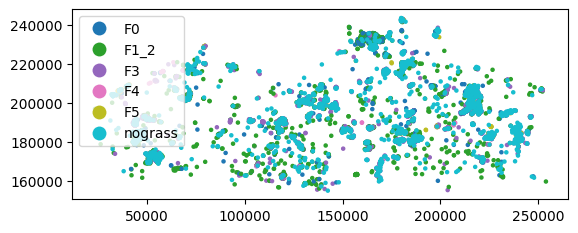

In [33]:
datagrassbwk2019.plot(column="Level4", legend=True, markersize=5)


# Creat full dataset

In [34]:
from geotessera import GeoTessera
import numpy as np
from geotessera.store import GeoTesseraZarr

#gt = GeoTessera(dataset_version='v1.1', dataset_variant='cambridge')

In [35]:
points = datagrassbwk2019.to_crs("EPSG:4326")
points = points[["Level4","geometry"]]
points

,Level4,geometry
0,F1_2,POINT (2.94565 50.82923)
1,F1_2,POINT (2.94689 50.82904)
2,F1_2,POINT (2.9482 50.8287)
3,F1_2,POINT (2.94844 50.82837)
4,F1_2,POINT (2.94749 50.82812)
...,...,...
10607,nograss,POINT (5.62302 50.91942)
11291,nograss,POINT (5.60086 51.05723)
15820,nograss,POINT (2.57042 51.06295)
10309,nograss,POINT (5.64572 50.92968)


In [36]:
from geotessera.store import GeoTesseraZarr

gt = GeoTesseraZarr()
print(gt.years)  # [2017, 2018, ..., 2025]


[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [37]:
coords = [(geom.x, geom.y) for geom in points.geometry]

gt = GeoTesseraZarr()
print(gt.years)  # [2017, 2018, ..., 2025]

# Sample embeddings at specific points (no download needed)
X = gt.sample_points(coords, year=2019)
print(f"Shape: {X.shape}")



Output()

[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


Shape: (8763, 128)


In [38]:
X

array([[ 1.5644248 ,  0.        , -1.888099  , ...,  1.5104791 ,
         3.074904  , -2.6433384 ],
       [ 0.3458818 , -0.9223514 , -1.1529393 , ...,  0.40352875,
         2.3635256 , -3.8046997 ],
       [ 2.1973147 ,  1.8184674 ,  0.3788474 , ...,  0.83346426,
         1.3638506 , -4.091552  ],
       ...,
       [ 4.8697166 , -1.9197922 ,  2.4348583 , ...,  0.        ,
        -0.98330814, -0.0468242 ],
       [ 4.8160048 , -1.8805352 ,  0.45866713, ..., -3.027203  ,
        -0.13760014,  1.9722687 ],
       [ 4.97659   , -0.55859685,  0.3046892 , ...,  1.9804798 ,
         2.4375136 , -1.6250091 ]], dtype=float32)

In [39]:
import pandas as pd

# Convert embeddings to DataFrame
emb_df = pd.DataFrame(
    X,
    columns=[f"emb_{i}" for i in range(X.shape[1])]
)

# Keep desired columns from GeoDataFrame
out = pd.concat(
    [
        points[["Level4"]].reset_index(drop=True),
        points.geometry.x.rename("lon").reset_index(drop=True),
        points.geometry.y.rename("lat").reset_index(drop=True),
        emb_df
    ],
    axis=1
)

out

,Level4,lon,lat,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127
0,F1_2,2.945650,50.829231,1.564425,0.000000,-1.888099,3.830143,-0.107891,1.294696,-0.755240,...,-3.074904,-6.203753,-2.427556,-3.884089,-1.132859,-0.971022,-2.265719,1.510479,3.074904,-2.643338
1,F1_2,2.946892,50.829040,0.345882,-0.922351,-1.152939,4.208229,-1.037645,-0.288235,-2.651760,...,-3.285877,-7.321165,-2.767054,-3.689406,-1.844703,-1.787056,-2.594113,0.403529,2.363526,-3.804700
2,F1_2,2.948197,50.828701,2.197315,1.818467,0.378847,3.333857,1.742698,-1.363851,-3.864243,...,-2.803471,-5.682711,-2.651932,-3.485396,-1.060773,-1.060773,-3.636935,0.833464,1.363851,-4.091552
3,F1_2,2.948436,50.828369,0.331507,1.381280,2.873063,2.486305,0.552512,-1.712788,-2.707309,...,-1.381280,-6.409141,-3.259821,-6.685397,0.663015,0.165754,-4.420097,1.270778,2.044295,-3.204570
4,F1_2,2.947491,50.828123,4.786153,-0.701969,0.638154,3.126953,0.893415,-1.595384,-2.616430,...,-2.744061,-4.147999,-2.424984,-4.020368,-1.084861,0.191446,-3.190768,1.340123,2.042092,-2.297353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,nograss,5.623025,50.919418,3.489770,-1.457752,1.148532,3.268898,-0.706789,-3.754816,-3.180550,...,0.397569,-3.975687,-1.104358,-2.297064,-0.220872,-4.859173,-5.035871,-2.252889,0.485917,-0.927660
8759,nograss,5.600860,51.057226,4.310707,1.215840,-0.442124,1.271106,-1.381637,-2.265884,-2.873804,...,2.044822,-3.702786,-3.979114,-3.371193,1.436902,-0.773717,-2.376415,-1.492168,3.150132,0.773717
8760,nograss,2.570417,51.062955,4.869717,-1.919792,2.434858,0.468242,-0.046824,-4.073705,-3.184046,...,0.515066,-1.966616,-2.622155,-4.822892,-0.327769,-1.030132,-3.792760,0.000000,-0.983308,-0.046824
8761,nograss,5.645725,50.929683,4.816005,-1.880535,0.458667,1.926402,-1.605335,-3.806937,-2.064002,...,1.421868,-3.164803,-4.036271,-2.752003,-0.596267,-1.605335,-3.027203,-3.027203,-0.137600,1.972269


In [40]:
out.to_csv("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputTesseraEmbeddings/Tessera2019.csv", index=False)